Function: compute window-level vibration features and save a feature table.

Feature strategy:
1. Load window metadata and filtered IMU signals,
2. Reconstruct each window by run_id and time range,
3. Compute time-domain features (mean, std, RMS, peak-to-peak, energy, mean absolute value),
4. Compute frequency-band powers (1-5 Hz, 5-20 Hz, 20-40 Hz),
5. Save engineered features to data/processed/window_features.csv.

The output excludes raw sample sequences and is ready for analysis/modeling.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SAMPLE_RATE = 100  # Hz
IMU_COLS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

filtered_path = PROJECT_ROOT / 'data' / 'interim' / 'filtered' / 'filtered_dataset.csv'
cleaned_path = PROJECT_ROOT / 'data' / 'interim' / 'cleaned' / 'cleaned_dataset.csv'
windows_path = PROJECT_ROOT / 'data' / 'processed' / 'windowed_metadata.csv'

if filtered_path.exists():
    signal_path = filtered_path
    print('Using filtered dataset for feature extraction')
elif cleaned_path.exists():
    signal_path = cleaned_path
    print('Filtered dataset not found; using cleaned dataset')
else:
    raise FileNotFoundError('No source dataset found. Run 04_cleaning.ipynb and 04b_filtering.ipynb first.')

if not windows_path.exists():
    raise FileNotFoundError(f'Window metadata not found: {windows_path}. Run 05_windowing.ipynb first.')

signals_df = pd.read_csv(signal_path, low_memory=False)
windows_df = pd.read_csv(windows_path, low_memory=False)

missing_imu = [c for c in IMU_COLS if c not in signals_df.columns]
if missing_imu:
    raise KeyError(f'Missing IMU columns in source dataset: {missing_imu}')

required_signal_cols = ['run_id', 't_rel', 'label']
missing_required = [c for c in required_signal_cols if c not in signals_df.columns]
if missing_required:
    raise KeyError(f'Missing required columns in source dataset: {missing_required}')

signals_df = signals_df.sort_values(['run_id', 't_rel']).reset_index(drop=True)

print(f'Signals source: {signal_path}')
print(f'Signals shape: {signals_df.shape}')
print(f'Window metadata shape: {windows_df.shape}')


def band_power_fft(x, fs, f_low, f_high):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan

    x_centered = x - np.mean(x)
    n = len(x_centered)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    fft_vals = np.fft.rfft(x_centered)
    psd = (np.abs(fft_vals) ** 2) / n

    mask = (freqs >= f_low) & (freqs <= f_high)
    if not np.any(mask):
        return 0.0

    return float(np.trapezoid(psd[mask], freqs[mask]))


def compute_time_features(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return {
            'mean': np.nan,
            'std': np.nan,
            'rms': np.nan,
            'ptp': np.nan,
            'energy': np.nan,
            'mean_abs': np.nan,
        }

    return {
        'mean': float(np.mean(x)),
        'std': float(np.std(x)),
        'rms': float(np.sqrt(np.mean(x ** 2))),
        'ptp': float(np.ptp(x)),
        'energy': float(np.sum(x ** 2)),
        'mean_abs': float(np.mean(np.abs(x))),
    }


feature_rows = []

for _, w in windows_df.iterrows():
    run_id = w['run_id']
    t_start = float(w['t_start'])
    t_end = float(w['t_end'])

    window_signal = signals_df[(signals_df['run_id'] == run_id) & (signals_df['t_rel'] >= t_start) & (signals_df['t_rel'] <= t_end)]
    if window_signal.empty:
        continue

    row = {
        'window_id': int(w['window_id']),
        'run_id': run_id,
        'segment_id': int(w['segment_id']),
        'label': w['label'],
        't_start': t_start,
        't_end': t_end,
        'n_samples': int(len(window_signal)),
    }

    for col in IMU_COLS:
        sig = window_signal[col].to_numpy(dtype=float)
        tf = compute_time_features(sig)
        for k, v in tf.items():
            row[f'{col}_{k}'] = v

        row[f'{col}_bandpower_1_5Hz'] = band_power_fft(sig, SAMPLE_RATE, 1.0, 5.0)
        row[f'{col}_bandpower_5_20Hz'] = band_power_fft(sig, SAMPLE_RATE, 5.0, 20.0)
        row[f'{col}_bandpower_20_40Hz'] = band_power_fft(sig, SAMPLE_RATE, 20.0, 40.0)

    acc_mag = np.sqrt((window_signal[['ax', 'ay', 'az']] ** 2).sum(axis=1).to_numpy(dtype=float))
    gyro_mag = np.sqrt((window_signal[['gx', 'gy', 'gz']] ** 2).sum(axis=1).to_numpy(dtype=float))

    for prefix, sig in [('acc_mag', acc_mag), ('gyro_mag', gyro_mag)]:
        tf = compute_time_features(sig)
        for k, v in tf.items():
            row[f'{prefix}_{k}'] = v

        row[f'{prefix}_bandpower_1_5Hz'] = band_power_fft(sig, SAMPLE_RATE, 1.0, 5.0)
        row[f'{prefix}_bandpower_5_20Hz'] = band_power_fft(sig, SAMPLE_RATE, 5.0, 20.0)
        row[f'{prefix}_bandpower_20_40Hz'] = band_power_fft(sig, SAMPLE_RATE, 20.0, 40.0)

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows).sort_values('window_id').reset_index(drop=True)
if features_df.empty:
    raise RuntimeError('No features were generated. Check window metadata and source signals.')

# Keep only identifiers, label, and engineered features (no raw sample values)
id_cols = ['window_id', 'run_id', 'segment_id', 'label', 't_start', 't_end', 'n_samples']
feature_cols = [c for c in features_df.columns if c not in id_cols]
features_df = features_df[id_cols + feature_cols]

output_dir = PROJECT_ROOT / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
features_path = output_dir / 'window_features.csv'
features_df.to_csv(features_path, index=False)

print(f'Generated window-level vibration features: {features_df.shape}')
print(f'Saved features to: {features_path}')
print('Label distribution:')
print(features_df['label'].value_counts().sort_index().to_string())
print('\nFeature preview:')
print(features_df.head())

Using filtered dataset for feature extraction
Signals source: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/filtered/filtered_dataset.csv
Signals shape: (211705, 14)
Window metadata shape: (1729, 9)
Generated window-level vibration features: (1729, 79)
Saved features to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/window_features.csv
Label distribution:
label
dry_dirt_track      652
grass               386
muddy_dirt_track    145
smooth_terrain      546

Feature preview:
   window_id                   run_id  segment_id  label  t_start   t_end  \
0          0  log_20260223_142511.490           7  grass   312.23  314.24   
1          1  log_20260223_142511.490          27  grass   317.69  319.70   
2          2  log_20260223_142511.490          28  grass   319.87  321.87   
3          3  log_20260223_142511.490          37  grass   328.83  330.86   
4          4  log_20260223_142511.490  

## 2. Feature Visualization (Pre-ML EDA)

This section visualizes engineered features to assess class separability before training models.

Plots included:
1. Per-label feature distributions (histogram + violin)
2. Correlation heatmap and highly correlated feature pairs
3. PCA 2D projection by label
4. t-SNE 2D projection by label

All figures are also saved to `reports/features/`.

In [2]:
# EDA setup and plotting utilities
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

RANDOM_STATE = 42
TOP_N_HEATMAP = 20
TSNE_SAMPLE_CAP = 2500  # Keep runtime predictable if dataset grows.

reports_dir = PROJECT_ROOT / 'reports' / 'features'
reports_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150

# Features used for plotting (exclude IDs/labels/time columns)
id_cols = ['window_id', 'run_id', 'segment_id', 'label', 't_start', 't_end', 'n_samples']
model_feature_cols = [c for c in features_df.columns if c not in id_cols]

print(f'EDA output directory: {reports_dir}')
print(f'Engineered feature columns for visualization: {len(model_feature_cols)}')

EDA output directory: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features
Engineered feature columns for visualization: 72


In [3]:
# Data diagnostics before plotting
print('Feature table diagnostics')
print('=' * 80)
print(f'Shape: {features_df.shape}')
print(f'Feature count: {len(model_feature_cols)}')

missing_counts = features_df[model_feature_cols].isna().sum()
missing_total = int(missing_counts.sum())
print(f'Total missing values in feature columns: {missing_total}')
if missing_total > 0:
    print('Top columns with missing values:')
    print(missing_counts[missing_counts > 0].sort_values(ascending=False).head(10).to_string())

label_counts = features_df['label'].value_counts().sort_index()
label_pct = (label_counts / len(features_df) * 100).round(2)
label_summary = pd.DataFrame({'count': label_counts, 'pct': label_pct})
print('\nLabel distribution:')
print(label_summary.to_string())

key_check_cols = [
    'acc_mag_rms', 'acc_mag_std', 'acc_mag_energy',
    'gyro_mag_rms', 'gyro_mag_std', 'gyro_mag_energy'
]
key_check_cols = [c for c in key_check_cols if c in features_df.columns]
if key_check_cols:
    print('\nQuick summary (key separator candidates):')
    print(features_df.groupby('label')[key_check_cols].mean().round(4).to_string())

Feature table diagnostics
Shape: (1729, 79)
Feature count: 72
Total missing values in feature columns: 0

Label distribution:
                  count    pct
label                         
dry_dirt_track      652  37.71
grass               386  22.33
muddy_dirt_track    145   8.39
smooth_terrain      546  31.58

Quick summary (key separator candidates):
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  gyro_mag_energy
label                                                                                                  
dry_dirt_track         1.0186       0.1008        207.6098       11.9358        1.9738       28903.1707
grass                  1.0166       0.0782        206.9068       12.2009        2.4188       30506.9005
muddy_dirt_track       1.0181       0.1073        207.3640       11.3092        2.1882       26162.1343
smooth_terrain         1.0183       0.1128        207.4510       10.7476        1.2551       23348.0550


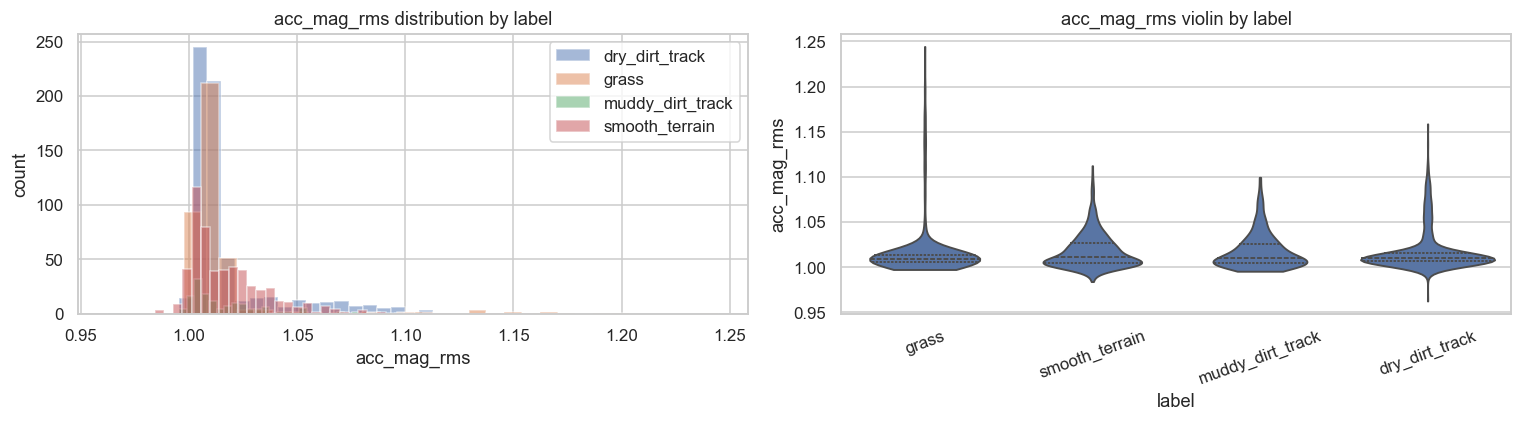

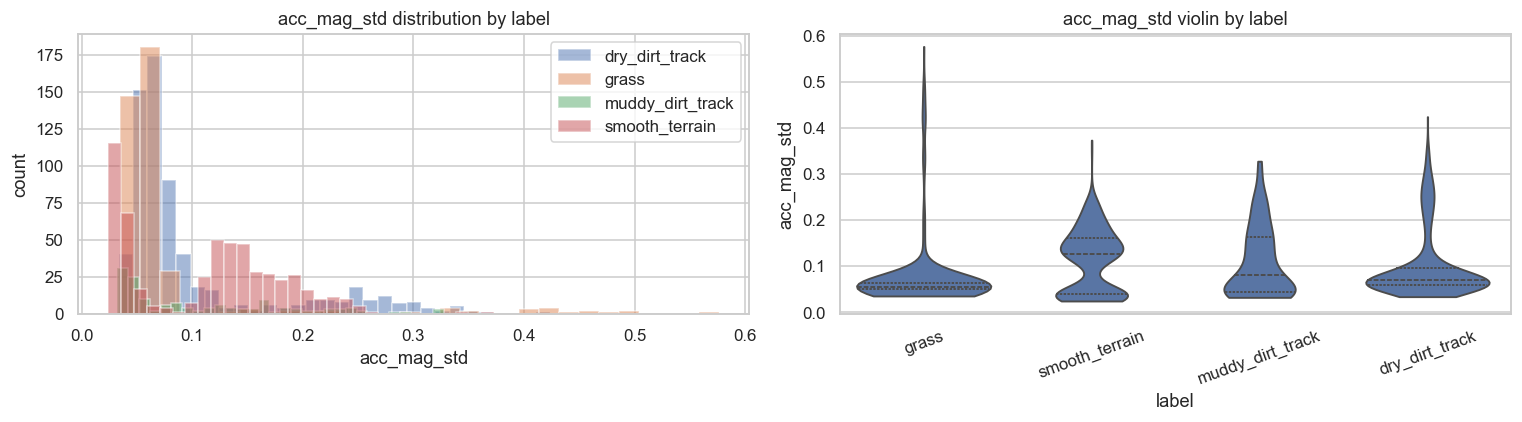

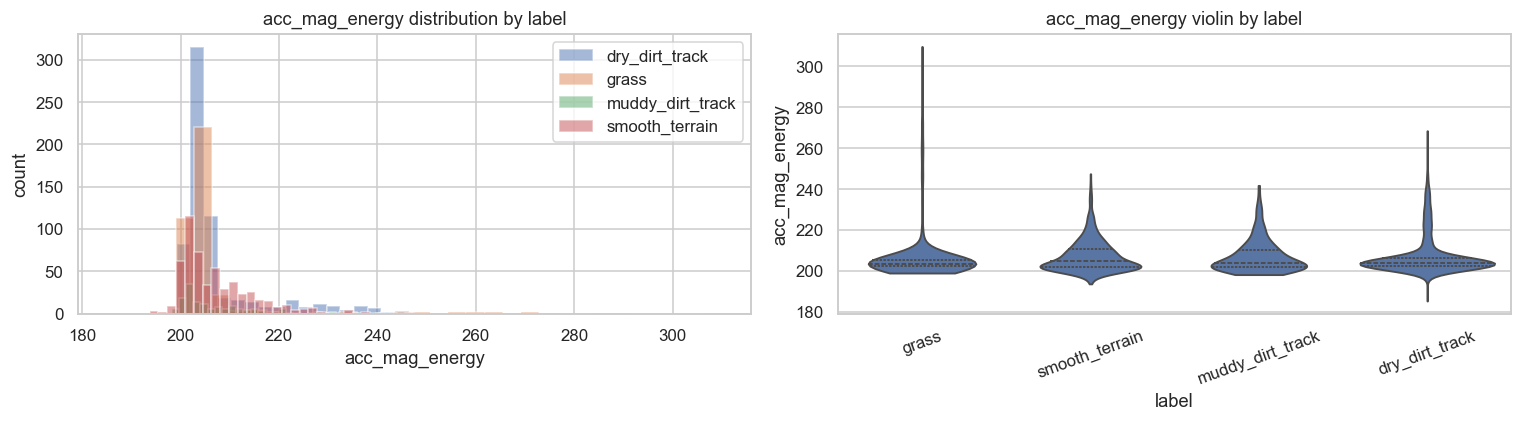

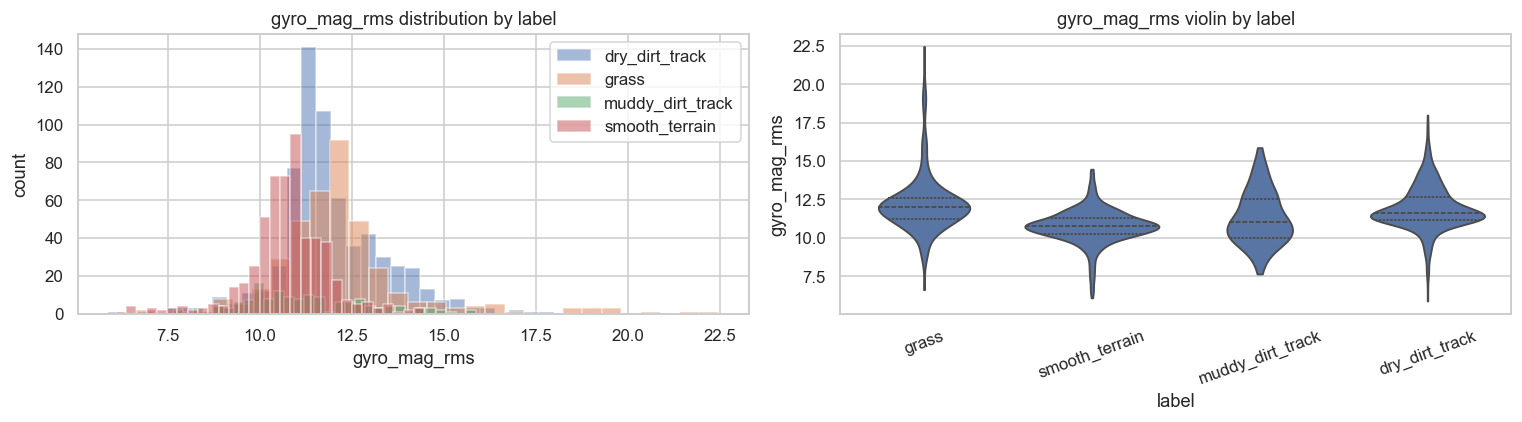

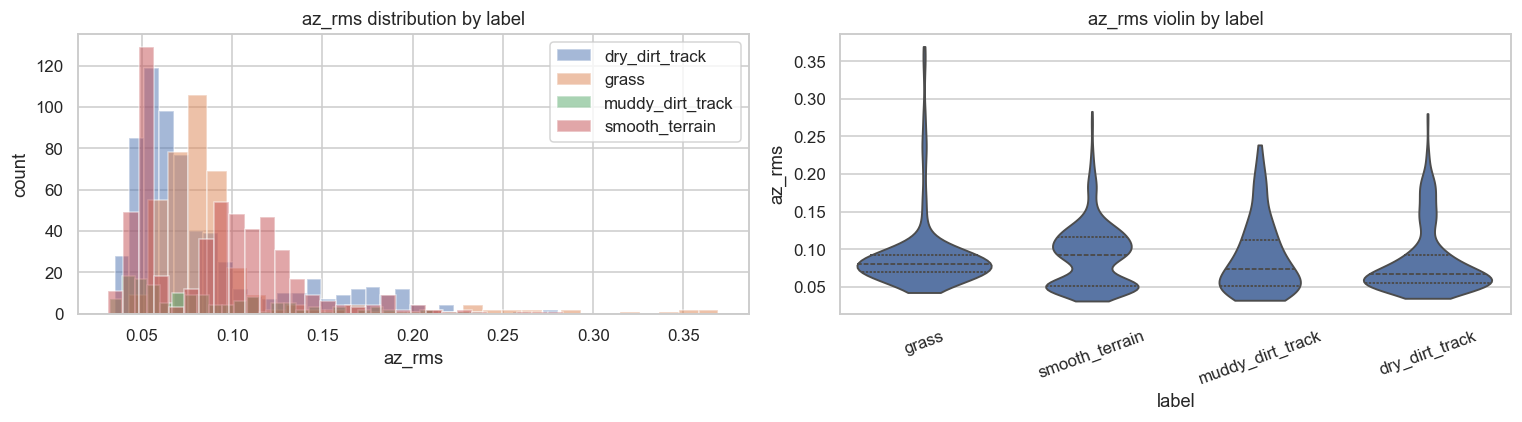

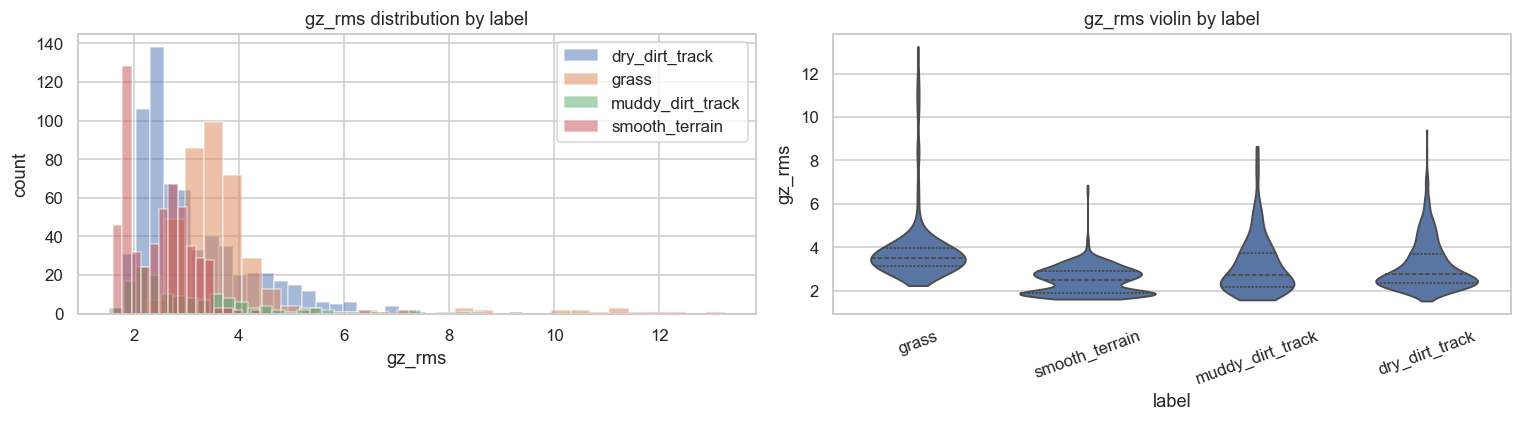

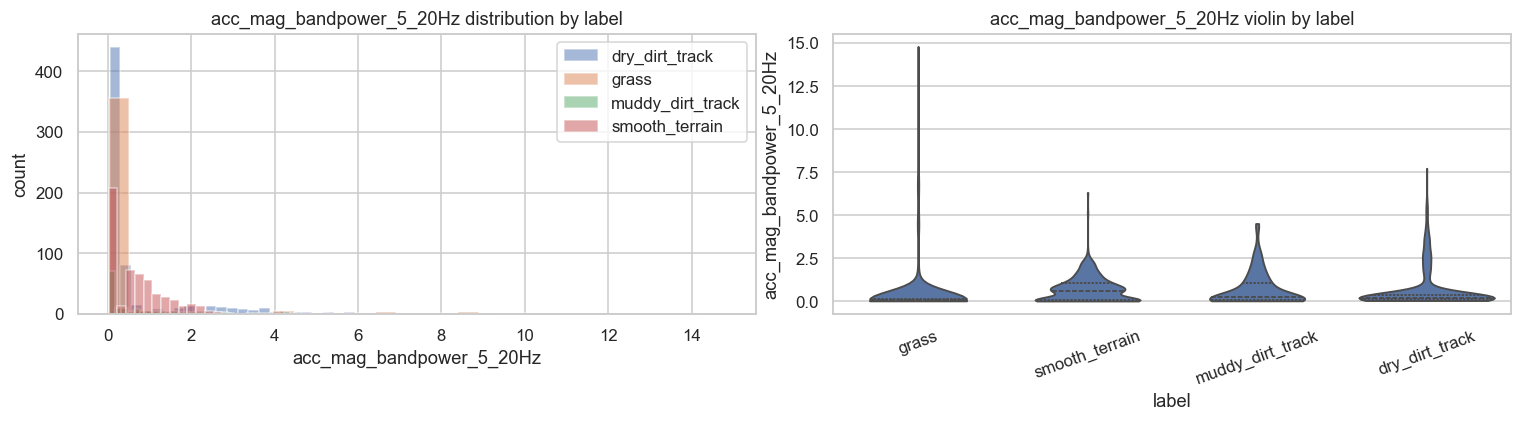

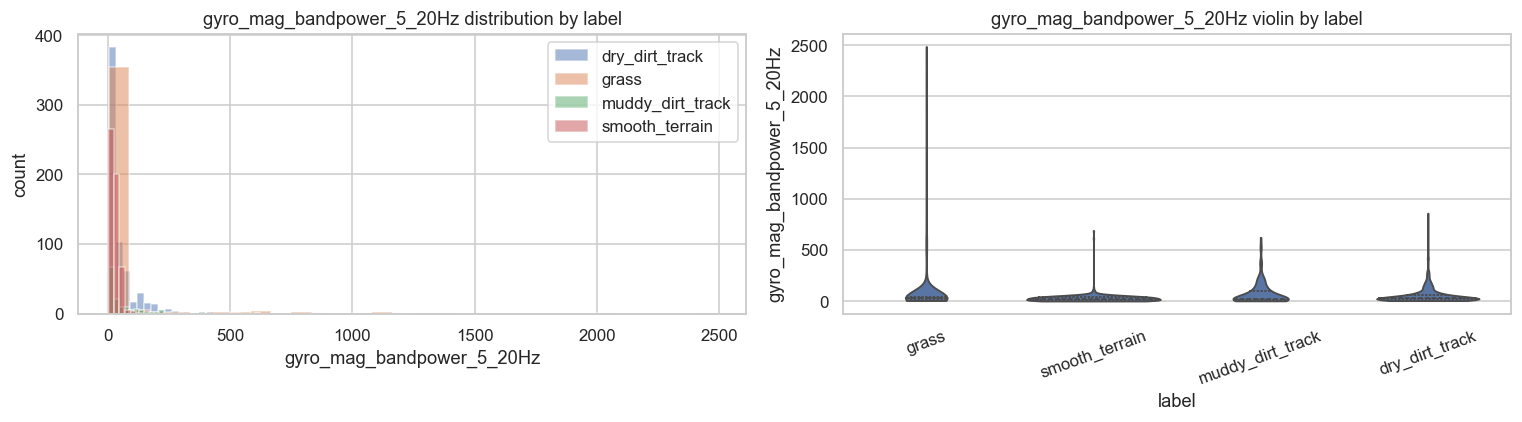

Saved 8 distribution figures to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features


In [4]:
# Per-label distributions: histogram + violin for selected features
viz_features = [
    'acc_mag_rms', 'acc_mag_std', 'acc_mag_energy',
    'gyro_mag_rms', 'az_rms', 'gz_rms',
    'acc_mag_bandpower_5_20Hz', 'gyro_mag_bandpower_5_20Hz'
]
viz_features = [c for c in viz_features if c in features_df.columns]

if not viz_features:
    raise RuntimeError('No requested visualization features were found in features_df.')

for feat in viz_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for label_name, g in features_df.groupby('label'):
        axes[0].hist(g[feat].dropna(), bins=30, alpha=0.5, label=label_name)

    axes[0].set_title(f'{feat} distribution by label')
    axes[0].set_xlabel(feat)
    axes[0].set_ylabel('count')
    axes[0].legend()

    sns.violinplot(data=features_df, x='label', y=feat, ax=axes[1], inner='quartile', cut=0)
    axes[1].set_title(f'{feat} violin by label')
    axes[1].tick_params(axis='x', rotation=20)

    fig.tight_layout()
    out_path = reports_dir / f'dist_{feat}.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()

print(f'Saved {len(viz_features)} distribution figures to {reports_dir}')

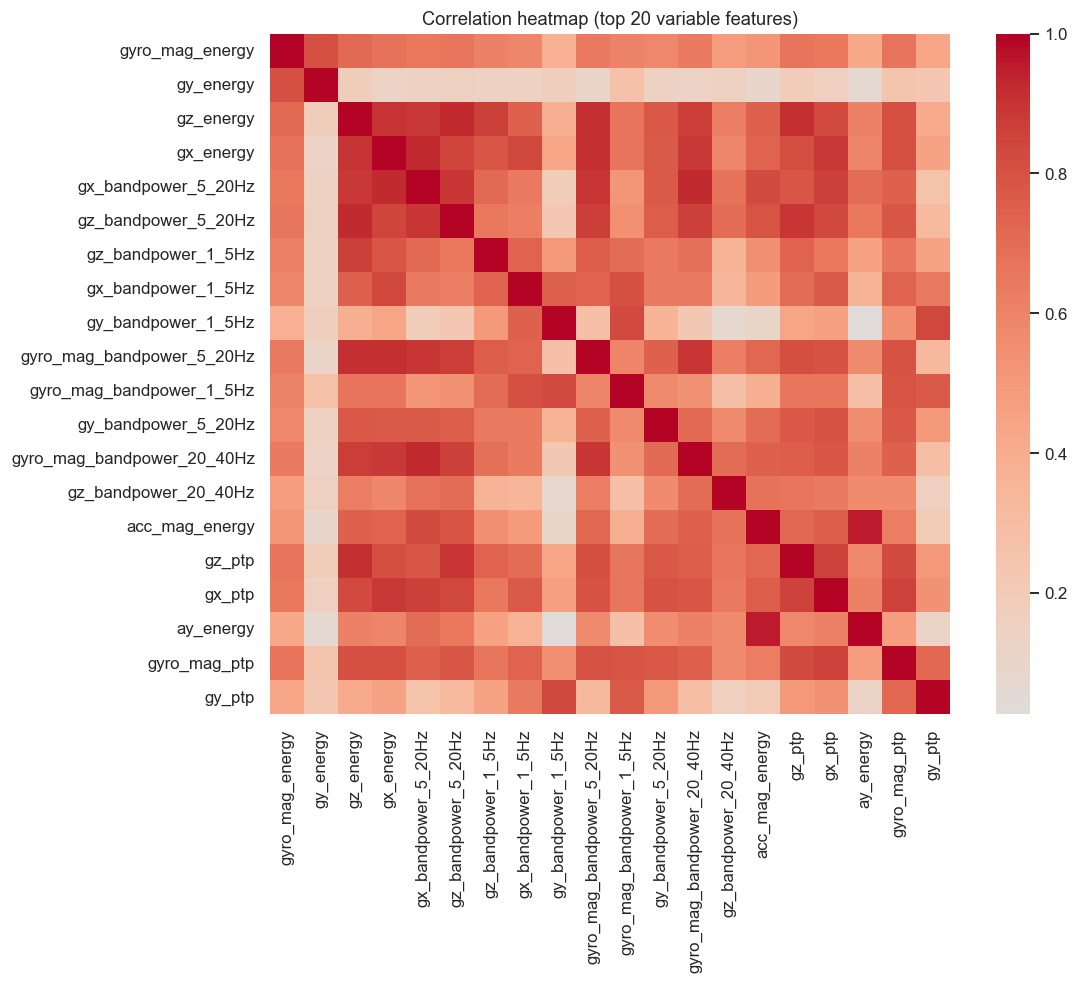

Top 15 absolute correlations among heatmap features:
                feature_1                  feature_2     corr
           acc_mag_energy                  ay_energy 0.951016
                gz_energy        gz_bandpower_5_20Hz 0.927686
                gx_energy        gx_bandpower_5_20Hz 0.925640
      gx_bandpower_5_20Hz gyro_mag_bandpower_20_40Hz 0.920962
                gz_energy  gyro_mag_bandpower_5_20Hz 0.912211
                gx_energy  gyro_mag_bandpower_5_20Hz 0.911382
                gz_energy                     gz_ptp 0.909031
                gz_energy                  gx_energy 0.900178
gyro_mag_bandpower_5_20Hz gyro_mag_bandpower_20_40Hz 0.896404
      gx_bandpower_5_20Hz  gyro_mag_bandpower_5_20Hz 0.895820
      gx_bandpower_5_20Hz        gz_bandpower_5_20Hz 0.890673
      gz_bandpower_5_20Hz                     gz_ptp 0.890182
                gx_energy                     gx_ptp 0.889052
                gz_energy        gx_bandpower_5_20Hz 0.886512
                g

In [5]:
# Correlation heatmap + highly correlated pair report
feature_std = features_df[model_feature_cols].std(numeric_only=True)
ranked = feature_std.sort_values(ascending=False)
heatmap_cols = ranked.head(min(TOP_N_HEATMAP, len(ranked))).index.tolist()

corr = features_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title(f'Correlation heatmap (top {len(heatmap_cols)} variable features)')
fig.tight_layout()
fig.savefig(reports_dir / 'corr_heatmap.png', bbox_inches='tight')
plt.show()

pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr.iloc[i, j]
        pairs.append((cols[i], cols[j], val, abs(val)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr', 'abs_corr'])
high_corr = pairs_df.sort_values('abs_corr', ascending=False).head(15)

print('Top 15 absolute correlations among heatmap features:')
print(high_corr[['feature_1', 'feature_2', 'corr']].to_string(index=False))

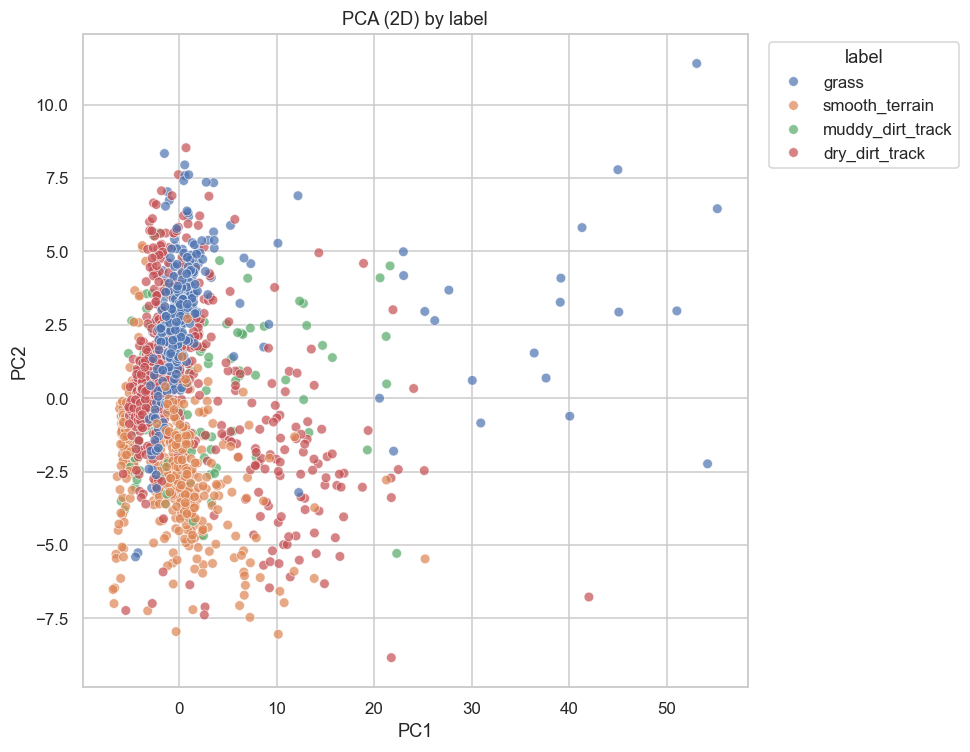

PCA explained variance ratio: [0.56904431 0.10538574]
PCA cumulative explained variance: 0.6744300506675193


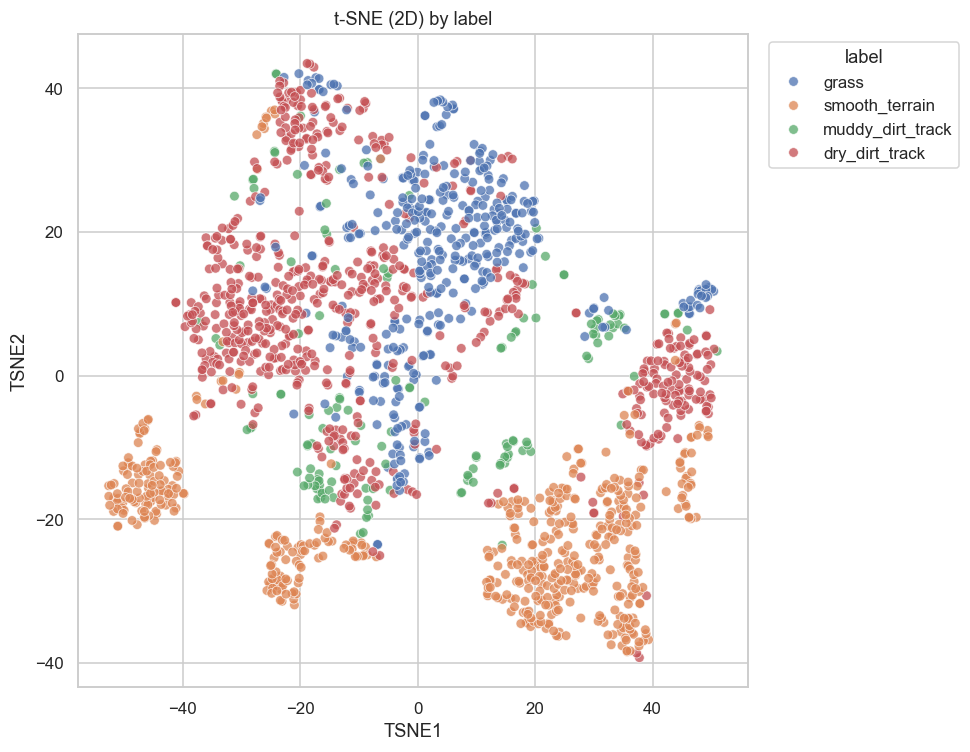

Saved PCA and t-SNE figures to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features


In [6]:
# PCA and t-SNE projections by label
X = features_df[model_feature_cols].to_numpy(dtype=float)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': features_df['label'].values,
})

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', alpha=0.7, s=40, ax=ax)
ax.set_title('PCA (2D) by label')
ax.legend(title='label', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(reports_dir / 'pca_2d.png', bbox_inches='tight')
plt.show()

print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('PCA cumulative explained variance:', pca.explained_variance_ratio_.sum())

# t-SNE (optional capped sample size for speed)
tsne_input = X_scaled
tsne_labels = features_df['label'].to_numpy()
if len(X_scaled) > TSNE_SAMPLE_CAP:
    sampled_df = features_df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(n=max(1, int(TSNE_SAMPLE_CAP * len(g) / len(features_df))), random_state=RANDOM_STATE)
    )
    sampled_df = sampled_df.sort_values('window_id').reset_index(drop=True)
    tsne_input = scaler.fit_transform(sampled_df[model_feature_cols].to_numpy(dtype=float))
    tsne_labels = sampled_df['label'].to_numpy()

perplexity = min(30, max(5, len(tsne_input) - 1))
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perplexity, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(tsne_input)

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'label': tsne_labels,
})

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='label', alpha=0.75, s=40, ax=ax)
ax.set_title('t-SNE (2D) by label')
ax.legend(title='label', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(reports_dir / 'tsne_2d.png', bbox_inches='tight')
plt.show()

print(f'Saved PCA and t-SNE figures to: {reports_dir}')